### Process Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

fasta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_variant_effect/paper_analysis/figure_1/output/OL41_42.csv")

def load_and_filter_data(file_path, dna_threshold=20, id_pattern='wC|wL|wR'):
    data = pd.read_csv(file_path, sep="\t")
    data = data[(data["lfcSE"] > -1) & (data["lfcSE"] < 1)]
    
    filtered_data = data[data['ID'].str.contains(id_pattern, regex=True)].copy()

    merged_filtered_data = pd.merge(
    filtered_data,          
    fasta_df,                
    left_on="ID",            
    right_on="Sequence_ID",  
    how="inner"              
    )
    
    merged_filtered_data["base_ID"] = merged_filtered_data["ID"].str.split(":").str[4]
    merged_filtered_data["core_ID"] = (
        merged_filtered_data["ID"].str.split(":").str[:4].str.join(":") + ":" + merged_filtered_data["window"]
    )
    return merged_filtered_data

def calculate_variant_effect(group):
    if len(group["base_ID"].unique()) == 2:
        effect_a = group.loc[group["base_ID"] == "A", "log2FoldChange"].values[0]
        effect_r = group.loc[group["base_ID"] == "R", "log2FoldChange"].values[0]
        return effect_a - effect_r
    return None

def group_and_calculate_effects(data):
    variant_effects = (
        data.groupby("core_ID")
        .apply(calculate_variant_effect)
        .dropna()
        .reset_index(name="variant_effect")
    )
    return variant_effects

def process_variant_effects(variant_effects):
    df_wC = variant_effects[variant_effects["core_ID"].str.contains("center")].copy()
    df_wC.columns = ["core_ID", "variant_effect_wC"]
    df_wC["ID"] = df_wC["core_ID"].str.split(":").str[:-1].str.join(":")
    
    df_wL = variant_effects[variant_effects["core_ID"].str.contains("left")].copy()
    df_wL.columns = ["core_ID", "variant_effect_wL"]
    df_wL["ID"] = df_wL["core_ID"].str.split(":").str[:-1].str.join(":")
    
    df_wR = variant_effects[variant_effects["core_ID"].str.contains("right")].copy()
    df_wR.columns = ["core_ID", "variant_effect_wR"]
    df_wR["ID"] = df_wR["core_ID"].str.split(":").str[:-1].str.join(":")
    
    # Merge the data
    merged_df = df_wR.merge(df_wL, on="ID", how="inner").merge(df_wC, on="ID", how="inner")
    return merged_df

In [2]:
file_path = "/scratch/st-cdeboer-1/sambina/position_mpra/data/GTeX_experimental_data/ENCFF141ZOX.tsv"

filtered_data = load_and_filter_data(file_path)
variant_effects = group_and_calculate_effects(filtered_data)
merged_df = process_variant_effects(variant_effects)

/tmp/ipykernel_1334734/3535640379.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep="\t")


In [3]:
combined_core_ids = pd.concat([
    merged_df['core_ID'], 
    merged_df['core_ID_x'], 
    merged_df['core_ID_y']
], ignore_index=True)

filtered_df = filtered_data[filtered_data['core_ID'].isin(combined_core_ids)]
filtered_df

,ID,SNP,chr,pos,ref_allele,alt_allele,allele,window,strand,project,...,log2FoldChange,lfcSE,stat,pvalue,padj,Sequence_ID,Sequence,Length,base_ID,core_ID
784,1:108743140:C:G:A:wC,1:108743140:C:G,1,108743140,C,G,alt,center,fwd,GTEx,...,1.628236,0.082549,19.724483,1.329081e-86,1.857300e-85,1:108743140:C:G:A:wC,CCGGAAGTGAGGGAGCTGGGAGCTGGGTCTCGGGAGGTGCTGTGCG...,200,A,1:108743140:C:G:center
785,1:108743140:C:G:A:wC:Alt_1-108743178-A,1:108743140:C:G,1,108743140,C,G,alt,center,fwd,GTEx,...,1.697237,0.089240,19.018891,1.189746e-80,1.591765e-79,1:108743140:C:G:A:wC:Alt_1-108743178-A,CCGGAAGTGAGGGAGCTGGGAGCTGGGTCTCGGGAGGTGCTGTGCG...,200,A,1:108743140:C:G:center
786,1:108743140:C:G:A:wC:Alt_1-108743178-R,1:108743140:C:G,1,108743140,C,G,alt,center,fwd,GTEx,...,1.628236,0.082549,19.724483,1.329081e-86,1.857300e-85,1:108743140:C:G:A:wC:Alt_1-108743178-R,CCGGAAGTGAGGGAGCTGGGAGCTGGGTCTCGGGAGGTGCTGTGCG...,200,A,1:108743140:C:G:center
787,1:108743140:C:G:A:wL:Alt_1-108743178-A,1:108743140:C:G,1,108743140,C,G,alt,left,fwd,GTEx,...,0.132104,0.182032,0.725719,4.680108e-01,6.543670e-01,1:108743140:C:G:A:wL:Alt_1-108743178-A,CGGGGTCGACCTCTGCCCAGTTGCCAGTCCCGCTGTCAGCATGCGG...,200,A,1:108743140:C:G:left
788,1:108743140:C:G:A:wL:Alt_1-108743178-R,1:108743140:C:G,1,108743140,C,G,alt,left,fwd,GTEx,...,0.344669,0.190344,1.810772,7.017622e-02,1.579850e-01,1:108743140:C:G:A:wL:Alt_1-108743178-R,CGGGGTCGACCTCTGCCCAGTTGCCAGTCCCGCTGTCAGCATGCGG...,200,A,1:108743140:C:G:left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445843,X:44203136:G:A:R:wC:Alt_X-44203167-A,X:44203136:G:A,X,44203136,G,A,ref,center,fwd,GTEx,...,0.205183,0.404523,0.507223,6.119987e-01,7.701986e-01,X:44203136:G:A:R:wC:Alt_X-44203167-A,CCCCTCCACCCGCTTCATCCCCGCACACACTCAGCCAGGTCCTGGT...,200,R,X:44203136:G:A:center
445844,X:44203136:G:A:R:wL:Alt_X-44203167-A,X:44203136:G:A,X,44203136,G,A,ref,left,fwd,GTEx,...,0.261816,0.302230,0.866281,3.863361e-01,5.783052e-01,X:44203136:G:A:R:wL:Alt_X-44203167-A,TGAGGAGTCTTCTCTCTGCACACGCAGTGTGCACACACAAAGATTG...,200,R,X:44203136:G:A:left
445845,X:44203136:G:A:R:wL:Alt_X-44203167-R,X:44203136:G:A,X,44203136,G,A,ref,left,fwd,GTEx,...,0.111700,0.209308,0.533663,5.935748e-01,7.564636e-01,X:44203136:G:A:R:wL:Alt_X-44203167-R,TGAGGAGTCTTCTCTCTGCACACGCAGTGTGCACACACAAAGATTG...,200,R,X:44203136:G:A:left
445846,X:44203136:G:A:R:wR:Alt_X-44203047-A,X:44203136:G:A,X,44203136,G,A,ref,right,fwd,GTEx,...,0.630015,0.303288,2.077283,3.777546e-02,9.338195e-02,X:44203136:G:A:R:wR:Alt_X-44203047-A,GGGGGGCGGGGGACACCTCCGCGGCGCGTACCTCCTCCCCAGCCCC...,200,R,X:44203136:G:A:right


### Load Model

In [4]:
import pandas as pd
import torch
from torchinfo import summary
from tqdm import tqdm
import numpy as np
import sys
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
import json
import os
sys.path.append("/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022/benchmarks/human")

from prixfixe.autosome import AutosomeFinalLayersBlock
from prixfixe.bhi import BHIFirstLayersBlock, BHICoreBlock
from prixfixe.prixfixe import PrixFixeNet

def configure_device(device):
    """Configures the CUDA device."""
    device = torch.device(device)
    generator = torch.Generator()
    generator.manual_seed(42)
    return device, generator

def initialize_model(seq_size, generator):
    """Initializes the PrixFixeNet model."""
    first = BHIFirstLayersBlock(
        in_channels=5,
        out_channels=320,
        seqsize=seq_size,
        kernel_sizes=[9, 15],
        pool_size=1,
        dropout=0.2
    )

    core = BHICoreBlock(
        in_channels=first.out_channels,
        out_channels=320,
        seqsize=first.infer_outseqsize(),
        lstm_hidden_channels=320,
        kernel_sizes=[9, 15],
        pool_size=1,
        dropout1=0.2,
        dropout2=0.5
    )

    final = AutosomeFinalLayersBlock(in_channels=core.out_channels)

    model = PrixFixeNet(
        first=first,
        core=core,
        final=final,
        generator=generator
    )

    return model

def load_model_weights(model, model_log_dir, device):
    """Loads model weights from the specified path."""
    print(device)
    model.load_state_dict(torch.load(model_log_dir, map_location=torch.device(device)))
    model.eval()
    return model

def print_model_summary(model, seq_size):
    """Prints the model summary."""
    print(summary(model, (1, 5, seq_size)))
    
def add_reverse_column(filtered_data):
    """Add a reverse column indicating if '_Reversed:' is present in the Sequence_ID."""
    filtered_data['rev'] = filtered_data['Sequence_ID'].str.contains('_Reversed:').astype(int)
    return filtered_data


def one_hot_encode(seq):
    """One-hot encode a DNA sequence."""
    mapping = {
        'A': [1, 0, 0, 0],
        'G': [0, 1, 0, 0],
        'C': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0]
    }
    return [mapping[base] for base in seq]


def encode_sequences(test_df, model_rnn, SEQ_SIZE, device):
    """One-hot encode the sequences and run predictions using the RNN model.
    If sequence length is < 200, add 'N' at the rightmost side.
    """
    encoded_seqs = []
    pred_expr_rnn = []
    for i, row in tqdm(test_df.iterrows()):
        seq = row['Sequence']
        if len(seq) < 200:
            seq = 'N'*(200-len(seq)) + seq 
        seq = "ACTGGCCGCTTGACG" + seq + "CACTGCGGCTCCTGCG"

        encoded_seq = one_hot_encode(seq)
        rev_value = [row['rev']] * len(encoded_seq)
        encoded_seq_with_rev = [list(encoded_base) + [rev] for encoded_base, rev in zip(encoded_seq, rev_value)]
        
        pred = model_rnn(torch.tensor(np.array(encoded_seq_with_rev).reshape(1, SEQ_SIZE, 5).transpose(0, 2, 1), device=device, dtype=torch.float32))
        pred_expr_rnn.append(pred.detach().cpu().flatten().tolist())
    
    return pred_expr_rnn



def save_predictions(test_df, pred_expr_rnn, OUTPUT):
    """Save the predicted values to a file."""
    os.makedirs(OUTPUT, exist_ok=True)

    file_path = f"{OUTPUT}/predicted_mean.txt"
    df = pd.DataFrame({
        'seq_id': test_df['Sequence_ID'],
        'prediction': pred_expr_rnn
    })
    
    df['prediction'] = df['prediction'].apply(lambda x: x[0])
    df.to_csv(file_path, index=False)
    return df

def test_metrics(df, test_df, OUTPUT):
    """Calculate and save Pearson and Spearman correlations."""
    pearson_corr, _ = pearsonr(df, test_df["prediction"])
    spearman_corr, _ = spearmanr(df, test_df["prediction"])
    
    metric_path = f"{OUTPUT}/test_metric.json"
    metrics_list = [{"pearsonr": pearson_corr}, {"spearmanr": spearman_corr}]
    
    with open(metric_path, 'a') as file:
        json.dump(metrics_list, file)

def main():
    CUDA_DEVICE_ID = "cpu"
    OUTPUT = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/OL42-prediction"
    MODEL_LOG_DIR = "/scratch/st-cdeboer-1/sambina/mpra/mpra_with_chromosome/gosai_2024/output_lfcse/output_k562/fold_4/model_best.pth"
    sys.path.append("/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022/benchmarks/human")

    SEQ_SIZE = 231

    device, generator = configure_device(CUDA_DEVICE_ID)
    model_rnn = initialize_model(SEQ_SIZE, generator)
    print_model_summary(model_rnn, SEQ_SIZE)
    model_rnn = load_model_weights(model_rnn, MODEL_LOG_DIR, device)


    filtered_data = load_and_filter_data(file_path)
    combined_core_ids = pd.concat([
    merged_df['core_ID'], 
    merged_df['core_ID_x'], 
    merged_df['core_ID_y']
    ], ignore_index=True)

# Filter 'filtered_data' based on the combined 'core_IDs'
    filtered_data_final = filtered_data[filtered_data['core_ID'].isin(combined_core_ids)]
    filtered_data_reversed = add_reverse_column(filtered_data_final)
    pred_expr_rnn = encode_sequences(filtered_data_reversed, model_rnn, SEQ_SIZE, device)
    predict_df = save_predictions(filtered_data_reversed, pred_expr_rnn, OUTPUT)
    test_metrics(filtered_data_reversed["log2FoldChange"], predict_df, OUTPUT)

    # calculate_and_save_grouped_metrics(df, test_df, OUTPUT)
if __name__ == "__main__":
    main()


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Layer (type:depth-idx)                   Output Shape              Param #
PrixFixeNet                              [1, 1]                    --
├─BHIFirstLayersBlock: 1-1               --                        --
│    └─ModuleList: 2-1                   --                        --
│    │    └─ConvBlock: 3-1               [1, 160, 231]             7,360
│    │    └─ConvBlock: 3-2               [1, 160, 231]             12,160
├─BHICoreBlock: 1-2                      --                        --
│    └─LSTM: 2-2                         [1, 231, 640]             1,643,520
│    └─ModuleList: 2-3                   --                        --
│    │    └─ConvBlock: 3-3               [1, 160, 231]             921,760
│    │    └─ConvBlock: 3-4               [1, 160, 231]             1,536,160
│    └─Dropout: 2-4                      [1, 320, 231]             --
├─AutosomeFinalLayersBlock: 1-3          --                        --
│    └─Conv1d: 2-5                       [1, 256, 231]     

/tmp/ipykernel_1334734/3535640379.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep="\t")
/tmp/ipykernel_1334734/246923588.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['rev'] = filtered_data['Sequence_ID'].str.contains('_Reversed:').astype(int)
8060it [2:53:38,  1.29s/it]


### Analyse predicted positional effects

In [2]:
import pandas as pd

def load_and_filter_data(file_path, id_pattern='wC|wL|wR'):
    data = pd.read_csv(file_path)
    filtered_data = data[data['seq_id'].str.contains(id_pattern, regex=True)].copy()
    filtered_data["base_ID"] = filtered_data["seq_id"].str.split(":").str[4]
    filtered_data["core_ID"] = (
        filtered_data['seq_id'].str.split(":").str[:4].str.join(":") + ":" + filtered_data['seq_id'].str.split(":").str[5]
    )
    return filtered_data

def calculate_variant_effect(group):
    if len(group["base_ID"].unique()) == 2:
        effect_a = group.loc[group["base_ID"] == "A", "prediction"].values[0]
        effect_r = group.loc[group["base_ID"] == "R", "prediction"].values[0]
        return effect_a - effect_r
    return None

def group_and_calculate_effects(data):
    variant_effects = (
        data.groupby("core_ID")
        .apply(calculate_variant_effect)
        .dropna()
        .reset_index(name="variant_effect")
    )
    return variant_effects


def process_variant_effects(variant_effects):
    # Filter for specific substrings and prepare merged DataFrame
    df_wC = variant_effects[variant_effects["core_ID"].str.contains("wC")].copy()
    df_wC.columns = ["core_ID", "variant_effect_wC"]
    df_wC["ID"] = df_wC["core_ID"].str.split(":").str[:-1].str.join(":")
    
    df_wL = variant_effects[variant_effects["core_ID"].str.contains("wL")].copy()
    df_wL.columns = ["core_ID", "variant_effect_wL"]
    df_wL["ID"] = df_wL["core_ID"].str.split(":").str[:-1].str.join(":")
    
    df_wR = variant_effects[variant_effects["core_ID"].str.contains("wR")].copy()
    df_wR.columns = ["core_ID", "variant_effect_wR"]
    df_wR["ID"] = df_wR["core_ID"].str.split(":").str[:-1].str.join(":")
    
    # Merge the data
    merged_df = df_wR.merge(df_wL, on="ID", how="inner").merge(df_wC, on="ID", how="inner")
    return merged_df

In [3]:
file_path = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/OL42-prediction/predicted_mean.txt"

filtered_data = load_and_filter_data(file_path)
print(filtered_data.head())
print(len(filtered_data))
predicted_variant_effects = group_and_calculate_effects(filtered_data)
print(predicted_variant_effects.head())
print(len(predicted_variant_effects))
merged_df = process_variant_effects(predicted_variant_effects)



                                   seq_id  prediction base_ID  \
0                    1:108743140:C:G:A:wC    1.813766       A   
1  1:108743140:C:G:A:wC:Alt_1-108743178-A    1.798017       A   
2  1:108743140:C:G:A:wC:Alt_1-108743178-R    1.813766       A   
3  1:108743140:C:G:A:wL:Alt_1-108743178-A    0.095560       A   
4  1:108743140:C:G:A:wL:Alt_1-108743178-R    0.190199       A   

              core_ID  
0  1:108743140:C:G:wC  
1  1:108743140:C:G:wC  
2  1:108743140:C:G:wC  
3  1:108743140:C:G:wL  
4  1:108743140:C:G:wL  
8060
                core_ID  variant_effect
0  10:100175529:CA:C:wC        0.626293
1  10:100175529:CA:C:wL        0.062428
2  10:100175529:CA:C:wR        0.304843
3   10:100175532:A:C:wC       -0.016753
4   10:100175532:A:C:wL        0.001095
1845


In [5]:
def create_heatmap(final_df, dataset_title):
    # Compute the correlation matrix and R² matrix
    pearson_corr = final_df.corr("pearson")
    r_squared_matrix = pearson_corr**2
    
    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(r_squared_matrix, dtype=bool))
    
    # Set up the figure
    plt.figure(figsize=(10, 8))
    
    # Create the heatmap
    heatmap = sns.heatmap(
        r_squared_matrix,
        mask=mask,
        cmap='coolwarm',
        annot=True,
        fmt=".2f",
        annot_kws={"size": 10},  # Adjust annotation style
        linewidths=0.5,  # Add gridlines for separation
        cbar_kws={"label": "Pearson R² (Variance Explained)", "shrink": 0.8},  # Customize the colorbar
        vmin=0, vmax=1  # R² values range from 0 to 1
    )
    
    # Add labels and adjust their style
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=45, fontsize=10)
    
    # Add a title for context
    plt.title(dataset_title, fontsize=12, pad=20)
    
    # Optimize layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()


def create_pairplot(final_df):
    # Create the pairplot
    g = sns.pairplot(final_df)
    for i in range(3):
        for j in range(3):
            if i <= j:  # Hide plots in the upper triangle and diagonal
                g.axes[i, j].set_visible(False)
            else:
                ax = g.axes[i, j]
                x_vals = np.array(ax.get_xlim())
                ax.plot(x_vals, x_vals, 'r--', linewidth=1)
                x_col = final_df.columns[j]
                y_col = final_df.columns[i]
                r, _ = pearsonr(final_df[x_col], final_df[y_col])
                r_squared = r ** 2
                ax.text(0.05, 0.9, f"$R^2 = {r_squared:.2f}$", transform=ax.transAxes, color='blue', fontsize=10)
    plt.show()

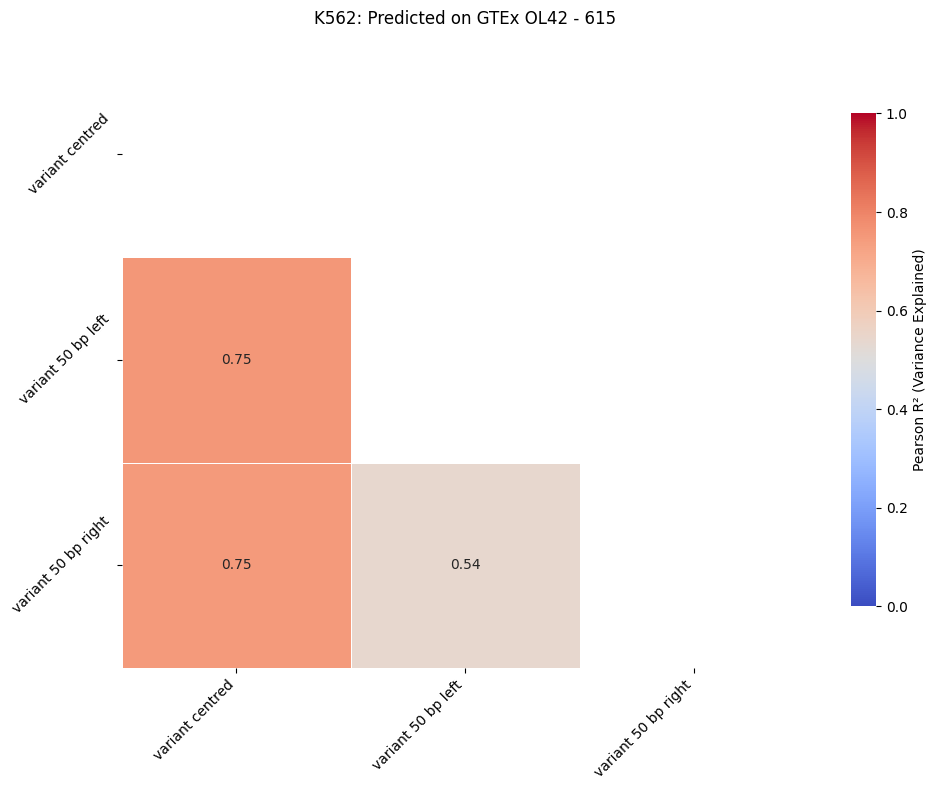

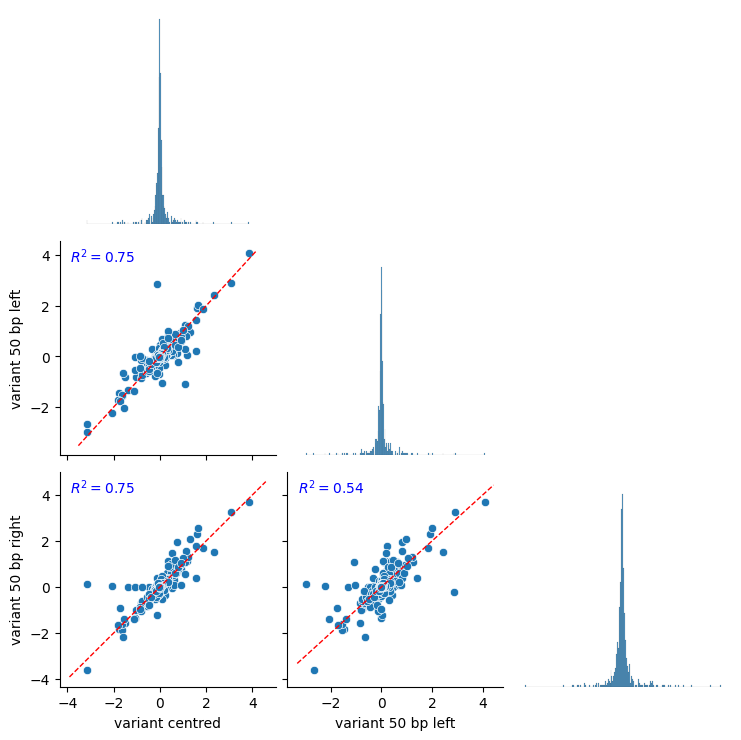

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
final_df = pd.DataFrame({
    "variant centred": merged_df["variant_effect_wC"].reset_index(drop=True),
    "variant 50 bp left": merged_df["variant_effect_wL"].reset_index(drop=True),
    "variant 50 bp right": merged_df["variant_effect_wR"].reset_index(drop=True)
})

# Generate Figures
create_heatmap(final_df, f"K562: Predicted on GTEx OL42 - {len(final_df)}")
create_pairplot(final_df)

### How does each stratified predicted vs original work

In [8]:
predicted_variant_effects

,core_ID,variant_effect
0,10:100175529:CA:C:wC,0.626293
1,10:100175529:CA:C:wL,0.062428
2,10:100175529:CA:C:wR,0.304843
3,10:100175532:A:C:wC,-0.016753
4,10:100175532:A:C:wL,0.001095
...,...,...
1840,X:202439:T:C:wL,-0.026781
1841,X:202439:T:C:wR,-0.015375
1842,X:44203136:G:A:wC,-0.022683
1843,X:44203136:G:A:wL,-0.014199


In [9]:
predicted_variant_effects['core_ID'] = predicted_variant_effects['core_ID'].str.replace('wC', 'center', regex=False)
predicted_variant_effects['core_ID'] = predicted_variant_effects['core_ID'].str.replace('wL', 'left', regex=False)
predicted_variant_effects['core_ID'] = predicted_variant_effects['core_ID'].str.replace('wR', 'right', regex=False)

print(predicted_variant_effects.head())
predicted_variant_effects.columns = ["core_ID", "predicted_variant_effect"]
print(predicted_variant_effects.head())

                    core_ID  variant_effect
0  10:100175529:CA:C:center        0.626293
1    10:100175529:CA:C:left        0.062428
2   10:100175529:CA:C:right        0.304843
3   10:100175532:A:C:center       -0.016753
4     10:100175532:A:C:left        0.001095
                    core_ID  predicted_variant_effect
0  10:100175529:CA:C:center                  0.626293
1    10:100175529:CA:C:left                  0.062428
2   10:100175529:CA:C:right                  0.304843
3   10:100175532:A:C:center                 -0.016753
4     10:100175532:A:C:left                  0.001095


In [10]:
merged_df = predicted_variant_effects.merge(variant_effects, on='core_ID', how='inner')


NameError: name 'variant_effects' is not defined

In [11]:
merged_df

,core_ID_x,variant_effect_wR,ID,core_ID_y,variant_effect_wL,core_ID,variant_effect_wC
0,10:100175529:CA:C:wR,0.304843,10:100175529:CA:C,10:100175529:CA:C:wL,0.062428,10:100175529:CA:C:wC,0.626293
1,10:100175532:A:C:wR,-0.029958,10:100175532:A:C,10:100175532:A:C:wL,0.001095,10:100175532:A:C:wC,-0.016753
2,10:114206754:G:C:wR,-0.128850,10:114206754:G:C,10:114206754:G:C:wL,-0.070546,10:114206754:G:C:wC,-0.126165
3,10:115439530:G:C:wR,0.085612,10:115439530:G:C,10:115439530:G:C:wL,0.067319,10:115439530:G:C:wC,0.104737
4,10:124017423:G:A:wR,0.130474,10:124017423:G:A,10:124017423:G:A:wL,0.106907,10:124017423:G:A:wC,0.071457
...,...,...,...,...,...,...,...
610,9:95899230:C:T:wR,0.021972,9:95899230:C:T,9:95899230:C:T:wL,0.026411,9:95899230:C:T:wC,0.014659
611,9:95899884:G:A:wR,-0.011688,9:95899884:G:A,9:95899884:G:A:wL,-0.051462,9:95899884:G:A:wC,-0.009895
612,9:95899933:G:C:wR,-0.044549,9:95899933:G:C,9:95899933:G:C:wL,-0.053718,9:95899933:G:C:wC,0.004020
613,X:202439:T:C:wR,-0.015375,X:202439:T:C,X:202439:T:C:wL,-0.026781,X:202439:T:C:wC,0.010838


In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

pearson_corr, _ = pearsonr(merged_df['predicted_variant_effect'], merged_df['variant_effect'])

plt.figure(figsize=(8, 6))
plt.scatter(merged_df['predicted_variant_effect'], merged_df['variant_effect'], alpha=0.7, color='blue')

plt.text(0.05, 0.95, f'Pearson r = {pearson_corr:.2f}', 
         transform=plt.gca().transAxes, fontsize=12, color='red', 
         verticalalignment='top')

plt.title('Scatterplot of Predicted vs Measured Variant Effect')
plt.xlabel('Predicted Variant Effect')
plt.ylabel('Variant Effect')
plt.grid(True)

plt.show()



KeyError: 'predicted_variant_effect'

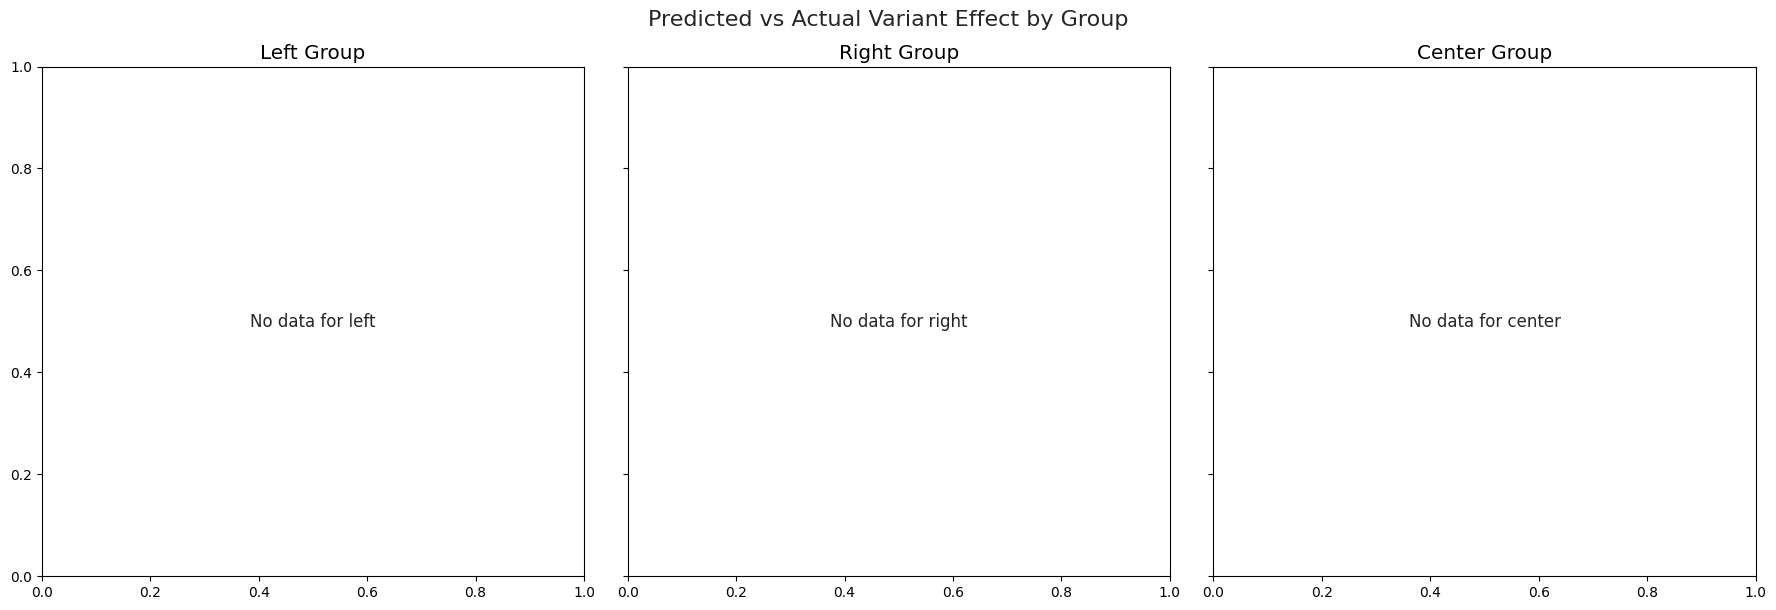

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

merged_df['group'] = merged_df['core_ID'].apply(lambda x: x.split(':')[-1])

groups = {
    'left': merged_df[merged_df['group'] == 'left'],
    'right': merged_df[merged_df['group'] == 'right'],
    'center': merged_df[merged_df['group'] == 'center']
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

sns.set(style="whitegrid", font_scale=1.2)

for ax, (group_name, group_df) in zip(axes, groups.items()):
    if group_df.empty:
        ax.text(0.5, 0.5, f"No data for {group_name}", 
                horizontalalignment='center', verticalalignment='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{group_name.capitalize()} Group')
        continue
    
    pearson_corr, _ = pearsonr(group_df['predicted_variant_effect'], group_df['variant_effect'])
    
    sns.scatterplot(
        x='predicted_variant_effect',
        y='variant_effect',
        data=group_df,
        color='blue',
        alpha=0.6,
        ax=ax
    )
    sns.regplot(
        x='predicted_variant_effect',
        y='variant_effect',
        data=group_df,
        scatter=False,
        color='red',
        ci=None,
        ax=ax
    )
    
    ax.text(0.05, 0.95, f'Pearson r = {pearson_corr:.2f}', 
            transform=ax.transAxes, fontsize=12, color='red', 
            verticalalignment='top')
    
    ax.set_title(f'{group_name.capitalize()} Group')
    ax.set_xlabel('Predicted Variant Effect')
    if ax == axes[0]:  # Only label the y-axis for the first plot
        ax.set_ylabel('Actual Variant Effect')
    else:
        ax.set_ylabel('')

plt.tight_layout()
fig.suptitle('Predicted vs Actual Variant Effect by Group', fontsize=16, y=1.02)
plt.show()



### Selecting the variants to do ISM on

In [14]:
predicted_variant_effects

,core_ID,predicted_variant_effect
0,10:100175529:CA:C:center,0.626293
1,10:100175529:CA:C:left,0.062428
2,10:100175529:CA:C:right,0.304843
3,10:100175532:A:C:center,-0.016753
4,10:100175532:A:C:left,0.001095
...,...,...
1840,X:202439:T:C:left,-0.026781
1841,X:202439:T:C:right,-0.015375
1842,X:44203136:G:A:center,-0.022683
1843,X:44203136:G:A:left,-0.014199


In [15]:
import itertools

predicted_variant_effects['base'] = predicted_variant_effects['core_ID'].apply(lambda x: ':'.join(x.split(':')[:4]))

def pairwise_squared_diff_sum(group):
    vals = group['predicted_variant_effect'].values
    diffs = [(a - b) ** 2 for a, b in itertools.combinations(vals, 2)]
    return sum(diffs)

# Apply to each group
result = predicted_variant_effects.groupby('base').apply(pairwise_squared_diff_sum)

# Step 3: Get the base with the largest total squared difference
max_base = result.idxmax()
max_value = result.max()

print("Base with largest total squared difference:", max_base)
print("Sum of squared differences:", max_value)



Base with largest total squared difference: 17:44139190:G:C
Sum of squared differences: 20.296889689714988


In [ ]:
sequence_dict = {
"A_wC": "TCTCCTCCAGGATTACTACTGTTAGTCTGTCTTTCCACCTCCAGTCTCTTGTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGCCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGCTGAAGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCTTGTCT", 
"R_wC": "TCTCCTCCAGGATTACTACTGTTAGTCTGTCTTTCCACCTCCAGTCTCTTGTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGCTGAAGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCTTGTCT",
"A_wL": "GTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGCCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGCTGAAGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCTTGTCTCTACTAAAAATACAAATATTAGCCAGGCGTCGTCGTGGGTGCCTGTGATC", 
"R_wL": "GTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGCTGAAGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCTTGTCTCTACTAAAAATACAAATATTAGCCAGGCGTCGTCGTGGGTGCCTGTGATC", 
"A_wR": "TTACATTTAAAATATTCCACATTCAGAGTTGTAGAGGCCTTAGACTATTATCTCCTCCAGGATTACTACTGTTAGTCTGTCTTTCCACCTCCAGTCTCTTGTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGCCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGC",
"R_wR": "TTACATTTAAAATATTCCACATTCAGAGTTGTAGAGGCCTTAGACTATTATCTCCTCCAGGATTACTACTGTTAGTCTGTCTTTCCACCTCCAGTCTCTTGTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGC"}


In [17]:
import itertools

# Step 1: Extract base from core_ID
predicted_variant_effects['base'] = predicted_variant_effects['core_ID'].apply(lambda x: ':'.join(x.split(':')[:4]))

# Step 2: Keep only groups with mixed sign effects
def has_mixed_signs(group):
    vals = group['predicted_variant_effect']
    return (vals > 0).any() and (vals < 0).any()

mixed_sign_df = predicted_variant_effects.groupby('base').filter(has_mixed_signs)

# Step 3: Function to compute sum of squared pairwise differences
def pairwise_squared_diff_sum(group):
    vals = group['predicted_variant_effect'].values
    diffs = [(a - b) ** 2 for a, b in itertools.combinations(vals, 2)]
    return sum(diffs)

# Step 4: Apply to each group and find the base with max difference
squared_diff_sums = mixed_sign_df.groupby('base').apply(pairwise_squared_diff_sum)

max_base = squared_diff_sums.idxmax()
max_value = squared_diff_sums.max()

# Output
print("Base with largest squared difference among mixed-sign groups:", max_base)
print("Sum of squared differences:", max_value)


Base with largest squared difference among mixed-sign groups: 17:44139190:G:C
Sum of squared differences: 20.296889689714988
